In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd


In [18]:
train_data = pd.read_csv("C:\\INTERVIEW PROJS\\NIS SYSTEM\\Train_data.csv")
test_data = pd.read_csv("C:\\INTERVIEW PROJS\\NIS SYSTEM\\Test_data.csv")

In [19]:
# Fill missing values
train_data = train_data.ffill()
test_data = test_data.ffill()

In [20]:
# Combine for consistent label encoding
combined = pd.concat([train_data, test_data], axis=0)

# Label Encoding for categorical columns
label_cols = ['protocol_type', 'service', 'flag', 'class']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    label_encoders[col] = le

# Put encoded columns back into train and test
train_data[label_cols] = combined.iloc[:len(train_data)][label_cols].values
test_data[label_cols] = combined.iloc[len(train_data):][label_cols].values



In [21]:
# Separate back
train_data = combined[:len(train_data)]
test_data = combined[len(train_data):]

# Features and Target
X_train = train_data.drop('class', axis=1)
y_train = train_data['class']
X_test = test_data.drop('class', axis=1)
y_test = test_data['class']

# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [22]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.0

Confusion Matrix:
 [[    0     0     0]
 [    0     0     0]
 [ 8362 14182     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00   22544.0

    accuracy                           0.00   22544.0
   macro avg       0.00      0.00      0.00   22544.0
weighted avg       0.00      0.00      0.00   22544.0



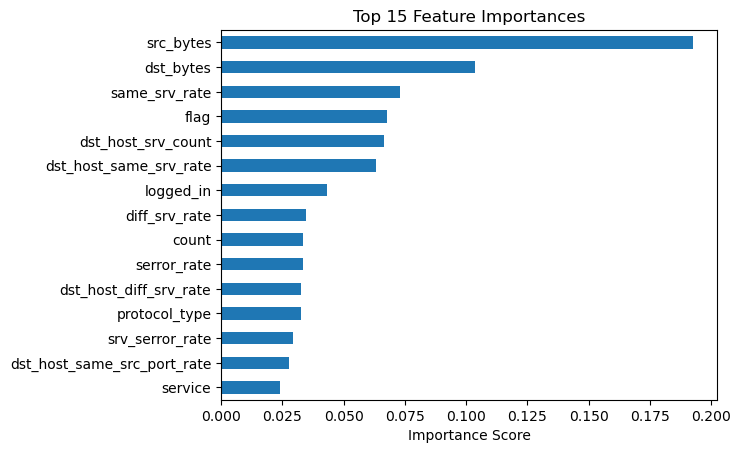

In [23]:
# Assuming X_train is a DataFrame
importances = rf.feature_importances_
features = X_train.columns

# Sort and plot
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()